# Mount Google Drive and Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
rar_path = '/content/drive/MyDrive/Dataset.rar'
extract_path = '/content/dataset'

os.makedirs(extract_path, exist_ok=True)

!unrar x "{rar_path}" "{extract_path}/"

Streaming output truncated to the last 5000 lines.
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-5822041-16.jpeg      95%  OK 
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-5822041-18.jpeg      95%  OK 
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-5822041-2.jpeg      95%  OK 
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-5822041-8.jpeg      95%  OK 
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-582215-6.jpeg      95%  OK 
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-582215-7.jpeg      95%  OK 
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-582215-8.jpeg      95%  OK 
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-5823731-1.jpeg      95%  OK 
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-5823731-5.jpeg      95%  OK 
Extracting  /content/dataset/Dataset/val/NORMAL/NORMAL-5824080-5.jpeg      95%  OK 
Extracting  /content

# Import Required Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Define Paths and Parameters

In [ ]:
# Define paths
base_dir = '/content/dataset/Dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
valid_dir = os.path.join(base_dir, 'val')

# Define classes
classes = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
num_classes = len(classes)

# Image parameters
img_height, img_width = 224, 224
batch_size = 32

# Class Distribution Analysis and Visualization

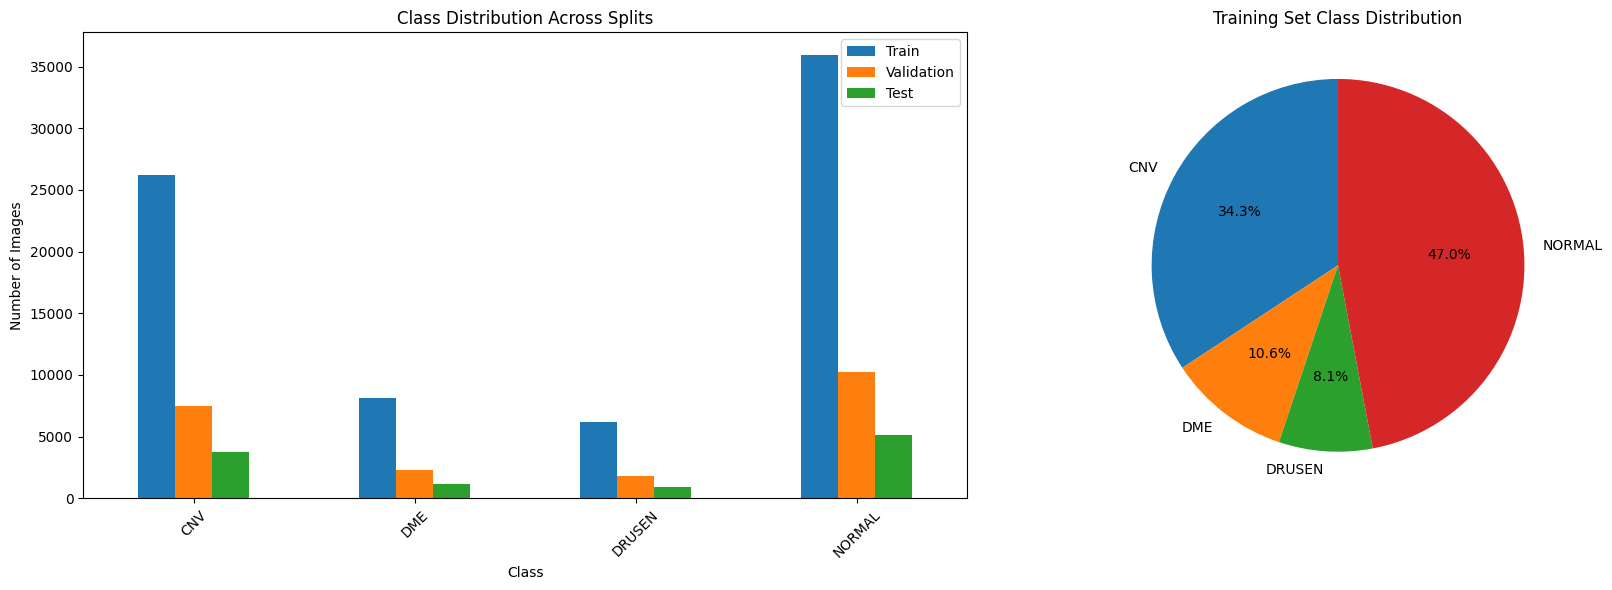

Class Distribution:
    Class  Train  Validation  Test
0     CNV  26218        7491  3746
1     DME   8118        2319  1161
2  DRUSEN   6206        1773   887
3  NORMAL  35973       10278  5139


In [ ]:
def visualize_class_distribution():
    os.makedirs('outputs', exist_ok=True)
    train_counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]
    val_counts = [len(os.listdir(os.path.join(valid_dir, cls))) for cls in classes]
    test_counts = [len(os.listdir(os.path.join(test_dir, cls))) for cls in classes]

    dist_df = pd.DataFrame({
        'Class': classes,
        'Train': train_counts,
        'Validation': val_counts,
        'Test': test_counts
    })

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Bar plot
    dist_df.set_index('Class').plot(kind='bar', ax=axes[0])
    axes[0].set_title('Class Distribution Across Splits')
    axes[0].set_ylabel('Number of Images')
    axes[0].tick_params(axis='x', rotation=45)

    # Pie chart for training set
    axes[1].pie(train_counts, labels=classes, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Training Set Class Distribution')

    plt.tight_layout()
    plt.savefig('outputs/class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    return dist_df, train_counts

distribution_df, train_counts = visualize_class_distribution()
print("Class Distribution:")
print(distribution_df)

# Sample Images Visualization

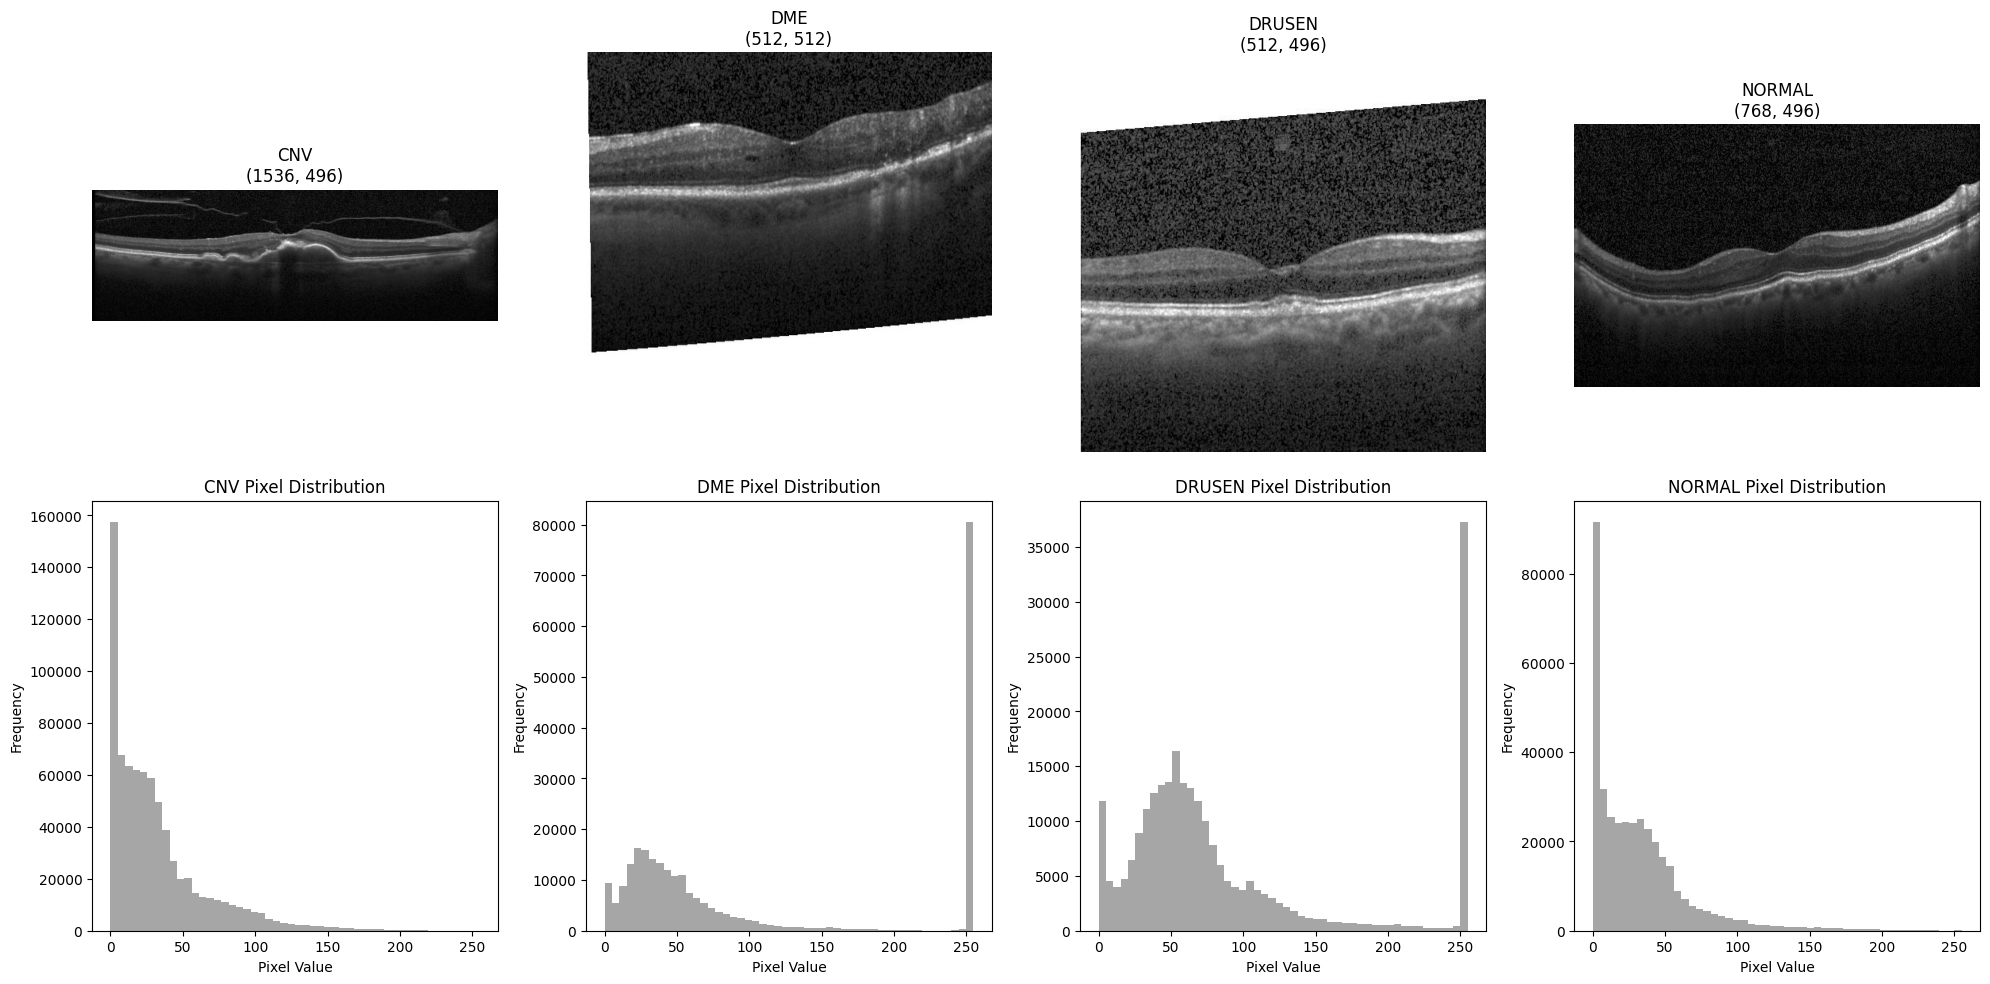

In [ ]:
def display_sample_images():
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()

    for i, class_name in enumerate(classes):
        class_path = os.path.join(train_dir, class_name)
        if os.path.exists(class_path):

            img_name = np.random.choice(os.listdir(class_path))
            img_path = os.path.join(class_path, img_name)

            img = Image.open(img_path)
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f'{class_name}\n{img.size}')
            axes[i].axis('off')

            # Display a histogram of pixel values
            img_array = np.array(img)
            axes[i+4].hist(img_array.ravel(), bins=50, color='gray', alpha=0.7)
            axes[i+4].set_title(f'{class_name} Pixel Distribution')
            axes[i+4].set_xlabel('Pixel Value')
            axes[i+4].set_ylabel('Frequency')

    plt.tight_layout()
    plt.savefig('outputs/sample_images.png', dpi=300, bbox_inches='tight')
    plt.show()

display_sample_images()

# Data generators setup

In [ ]:
# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='reflect'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Creating data generators...")

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=True,
    classes=classes
)

valid_generator = val_test_datagen.flow_from_directory(
    valid_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False,
    classes=classes
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False,
    classes=classes
)


# Calculate class weights to handle class imbalance
print("Calculating class weights...")
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)


Creating data generators...
Found 76515 images belonging to 4 classes.
Found 21861 images belonging to 4 classes.
Found 10933 images belonging to 4 classes.
Calculating class weights...
Class weights: {0: np.float64(0.7296037073766115), 1: np.float64(2.356337767923134), 2: np.float64(3.082299387689333), 3: np.float64(0.5317529814027188)}


# Visualize augmented images

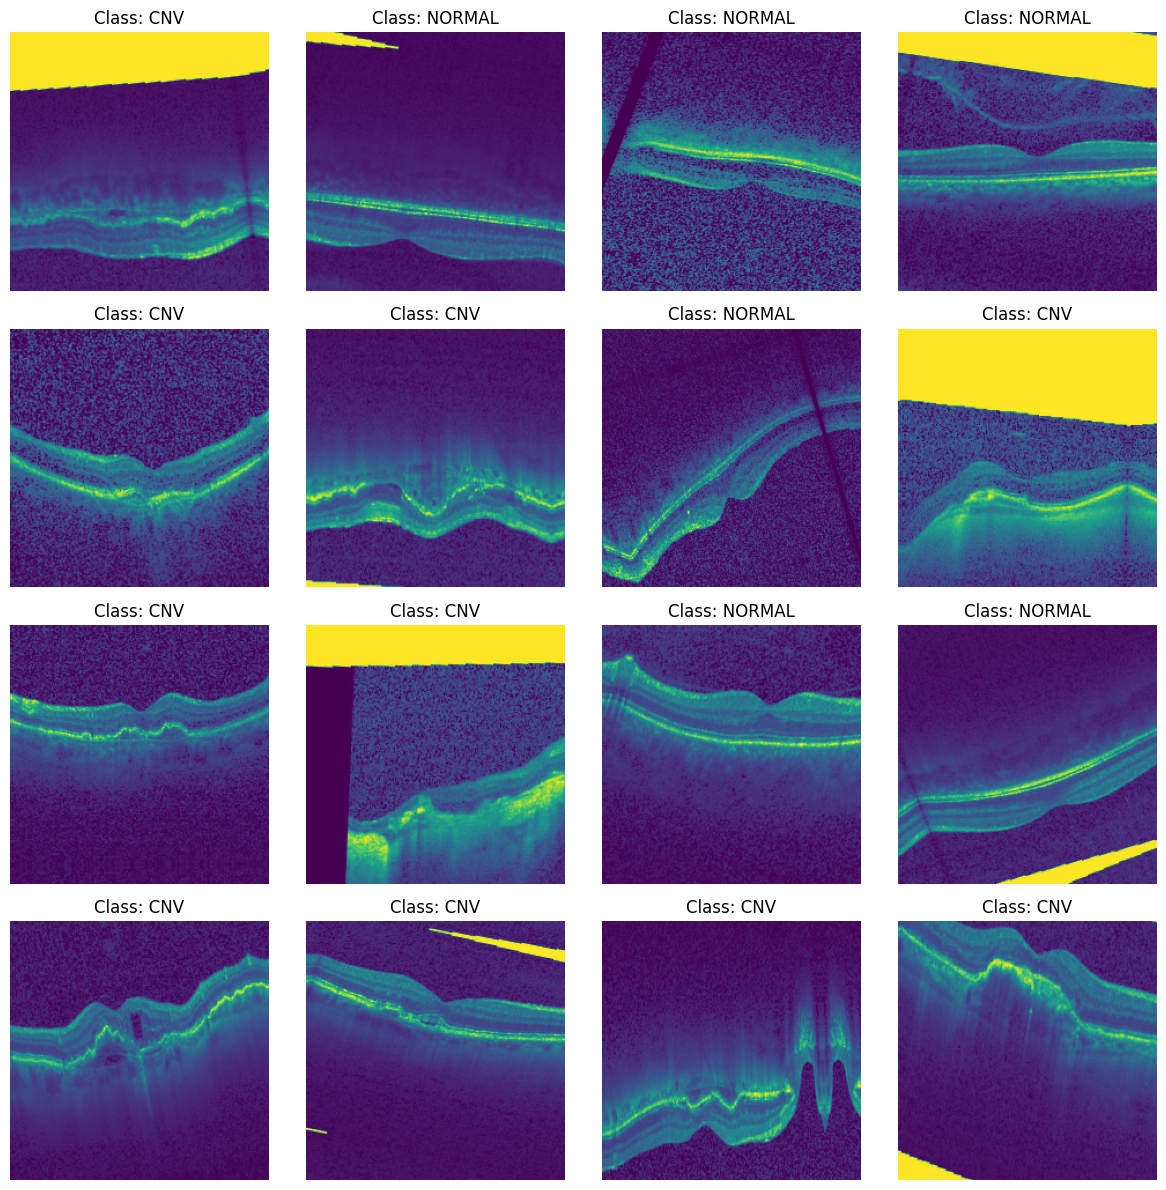

In [ ]:
def visualize_augmented_images():
    # Get a batch of images
    x_batch, y_batch = next(train_generator)

    # Plot augmented images
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.ravel()

    for i in range(16):
        axes[i].imshow(x_batch[i])
        axes[i].set_title(f'Class: {classes[np.argmax(y_batch[i])]}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('outputs/augmented_images.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_augmented_images()

# CNN Model Architecture Definition

In [ ]:
def create_oct_cnn_model(input_shape, num_classes):
    model = Sequential([
        # First Conv Block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Second Conv Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        # Third Conv Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        # Fourth Conv Block
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.5),

        # Fifth Conv Block
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.5),

        # Classifier
        Flatten(),
        Dense(1024, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.6),
        Dense(512, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model

input_shape = (img_height, img_width, 1)
model = create_oct_cnn_model(input_shape, num_classes)

# Compile the model
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall'),
                       tf.keras.metrics.AUC(name='auc', multi_label=True),
                       tf.keras.metrics.AUC(name='pr_auc', curve='PR')])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 30,943,716 (118.04 MB)

 Trainable params: 30,936,676 (118.01 MB)

 Non-trainable params: 7,040 (27.50 KB)

# Training Callbacks Setup

In [ ]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=8,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Calculate steps per epoch
train_steps = train_generator.samples // batch_size
valid_steps = valid_generator.samples // batch_size

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=30, --
    validation_data=valid_generator,
    validation_steps=valid_steps,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

Epoch 1/30
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.4964 - auc: 0.6502 - loss: 22.1906 - pr_auc: 0.5247 - precision: 0.5348 - recall: 0.4445
Epoch 1: val_auc improved from -inf to 0.76628, saving model to best_model.h5


2391/2391 ━━━━━━━━━━━━━━━━━━━━ 782s 311ms/step - accuracy: 0.4964 - auc: 0.6502 - loss: 22.1881 - pr_auc: 0.5248 - precision: 0.5349 - recall: 0.4445 - val_accuracy: 0.5551 - val_auc: 0.7663 - val_loss: 7.4897 - val_pr_auc: 0.6301 - val_precision: 0.5746 - val_recall: 0.5232 - learning_rate: 1.0000e-04
Epoch 2/30
   1/2391 ━━━━━━━━━━━━━━━━━━━━ 10:30 264ms/step - accuracy: 0.7188 - auc: 0.8153 - loss: 6.8299 - pr_auc: 0.8191 - precision: 0.8333 - recall: 0.6250

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_auc improved from 0.76628 to 0.77152, saving model to best_model.h5


2391/2391 ━━━━━━━━━━━━━━━━━━━━ 52s 22ms/step - accuracy: 0.7188 - auc: 0.8153 - loss: 6.8299 - pr_auc: 0.8191 - precision: 0.8333 - recall: 0.6250 - val_accuracy: 0.5751 - val_auc: 0.7715 - val_loss: 7.4232 - val_pr_auc: 0.6448 - val_precision: 0.5939 - val_recall: 0.5390 - learning_rate: 1.0000e-04
Epoch 3/30
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.7671 - auc: 0.8516 - loss: 4.7954 - pr_auc: 0.8444 - precision: 0.8214 - recall: 0.7210
Epoch 3: val_auc improved from 0.77152 to 0.92253, saving model to best_model.h5


...

2391/2391 ━━━━━━━━━━━━━━━━━━━━ 749s 313ms/step - accuracy: 0.8759 - auc: 0.9496 - loss: 0.8907 - pr_auc: 0.9343 - precision: 0.8892 - recall: 0.8607 - val_accuracy: 0.8910 - val_auc: 0.9584 - val_loss: 0.7503 - val_pr_auc: 0.9428 - val_precision: 0.8955 - val_recall: 0.8862 - learning_rate: 1.0000e-04
Epoch 8/30
   1/2391 ━━━━━━━━━━━━━━━━━━━━ 9:03 227ms/step - accuracy: 0.8438 - auc: 0.8429 - loss: 0.9925 - pr_auc: 0.8697 - precision: 0.8438 - recall: 0.8438
Epoch 8: val_auc did not improve from 0.95842
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 51s 21ms/step - accuracy: 0.8438 - auc: 0.8429 - loss: 0.9925 - pr_auc: 0.8697 - precision: 0.8438 - recall: 0.8438 - val_accuracy: 0.8899 - val_auc: 0.9581 - val_loss: 0.7539 - val_pr_auc: 0.9422 - val_precision: 0.8945 - val_recall: 0.8851 - learning_rate: 1.0000e-04
Epoch 9/30
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8965 - auc: 0.9622 - loss: 0.6726 - pr_auc: 0.9501 - precision: 0.9060 - recall: 0.8871
Epoch 9: val_auc improved from 0

2391/2391 ━━━━━━━━━━━━━━━━━━━━ 748s 312ms/step - accuracy: 0.8965 - auc: 0.9622 - loss: 0.6726 - pr_auc: 0.9501 - precision: 0.9060 - recall: 0.8871 - val_accuracy: 0.9314 - val_auc: 0.9813 - val_loss: 0.5204 - val_pr_auc: 0.9757 - val_precision: 0.9342 - val_recall: 0.9291 - learning_rate: 1.0000e-04
Epoch 10/30
   1/2391 ━━━━━━━━━━━━━━━━━━━━ 9:57 250ms/step - accuracy: 0.9688 - auc: 0.9947 - loss: 0.4591 - pr_auc: 0.9873 - precision: 0.9688 - recall: 0.9688
Epoch 10: val_auc did not improve from 0.98126
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 51s 21ms/step - accuracy: 0.9688 - auc: 0.9947 - loss: 0.4591 - pr_auc: 0.9873 - precision: 0.9688 - recall: 0.9688 - val_accuracy: 0.9311 - val_auc: 0.9807 - val_loss: 0.5246 - val_pr_auc: 0.9749 - val_precision: 0.9334 - val_recall: 0.9284 - learning_rate: 1.0000e-04
Epoch 11/30
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9114 - auc: 0.9703 - loss: 0.5708 - pr_auc: 0.9597 - precision: 0.9179 - recall: 0.9039
Epoch 11: val_auc did not imp

2391/2391 ━━━━━━━━━━━━━━━━━━━━ 688s 288ms/step - accuracy: 0.9379 - auc: 0.9821 - loss: 0.4517 - pr_auc: 0.9756 - precision: 0.9420 - recall: 0.9341 - val_accuracy: 0.9502 - val_auc: 0.9838 - val_loss: 0.4178 - val_pr_auc: 0.9799 - val_precision: 0.9520 - val_recall: 0.9487 - learning_rate: 1.0000e-04
Epoch 24/30
   1/2391 ━━━━━━━━━━━━━━━━━━━━ 9:18 234ms/step - accuracy: 1.0000 - auc: 0.7500 - loss: 0.3027 - pr_auc: 1.0000 - precision: 1.0000 - recall: 1.0000
Epoch 24: val_auc did not improve from 0.98381
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 51s 21ms/step - accuracy: 1.0000 - auc: 0.7500 - loss: 0.3027 - pr_auc: 1.0000 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9499 - val_auc: 0.9835 - val_loss: 0.4187 - val_pr_auc: 0.9796 - val_precision: 0.9517 - val_recall: 0.9484 - learning_rate: 1.0000e-04
Epoch 25/30
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9411 - auc: 0.9840 - loss: 0.4312 - pr_auc: 0.9780 - precision: 0.9446 - recall: 0.9376
Epoch 25: val_auc did not imp

2391/2391 ━━━━━━━━━━━━━━━━━━━━ 689s 284ms/step - accuracy: 0.9418 - auc: 0.9850 - loss: 0.4330 - pr_auc: 0.9790 - precision: 0.9453 - recall: 0.9387 - val_accuracy: 0.9445 - val_auc: 0.9846 - val_loss: 0.4342 - val_pr_auc: 0.9786 - val_precision: 0.9464 - val_recall: 0.9427 - learning_rate: 1.0000e-04
Epoch 28/30
   1/2391 ━━━━━━━━━━━━━━━━━━━━ 8:58 225ms/step - accuracy: 0.9375 - auc: 0.7500 - loss: 0.4247 - pr_auc: 0.9889 - precision: 0.9375 - recall: 0.9375
Epoch 28: val_auc did not improve from 0.98456
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - accuracy: 0.9375 - auc: 0.7500 - loss: 0.4247 - pr_auc: 0.9889 - precision: 0.9375 - recall: 0.9375 - val_accuracy: 0.9433 - val_auc: 0.9841 - val_loss: 0.4379 - val_pr_auc: 0.9778 - val_precision: 0.9451 - val_recall: 0.9413 - learning_rate: 1.0000e-04
Epoch 29/30
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9441 - auc: 0.9841 - loss: 0.4304 - pr_auc: 0.9782 - precision: 0.9471 - recall: 0.9406
Epoch 29: val_auc improved fr

2391/2391 ━━━━━━━━━━━━━━━━━━━━ 700s 288ms/step - accuracy: 0.9441 - auc: 0.9841 - loss: 0.4304 - pr_auc: 0.9782 - precision: 0.9471 - recall: 0.9406 - val_accuracy: 0.9496 - val_auc: 0.9889 - val_loss: 0.4036 - val_pr_auc: 0.9845 - val_precision: 0.9519 - val_recall: 0.9478 - learning_rate: 1.0000e-04
Epoch 30/30
   1/2391 ━━━━━━━━━━━━━━━━━━━━ 9:19 234ms/step - accuracy: 0.9688 - auc: 1.0000 - loss: 0.3192 - pr_auc: 0.9981 - precision: 0.9688 - recall: 0.9688
Epoch 30: val_auc did not improve from 0.98892
2391/2391 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - accuracy: 0.9688 - auc: 1.0000 - loss: 0.3192 - pr_auc: 0.9981 - precision: 0.9688 - recall: 0.9688 - val_accuracy: 0.9490 - val_auc: 0.9885 - val_loss: 0.4047 - val_pr_auc: 0.9841 - val_precision: 0.9515 - val_recall: 0.9475 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 29.


# Training History Visualization

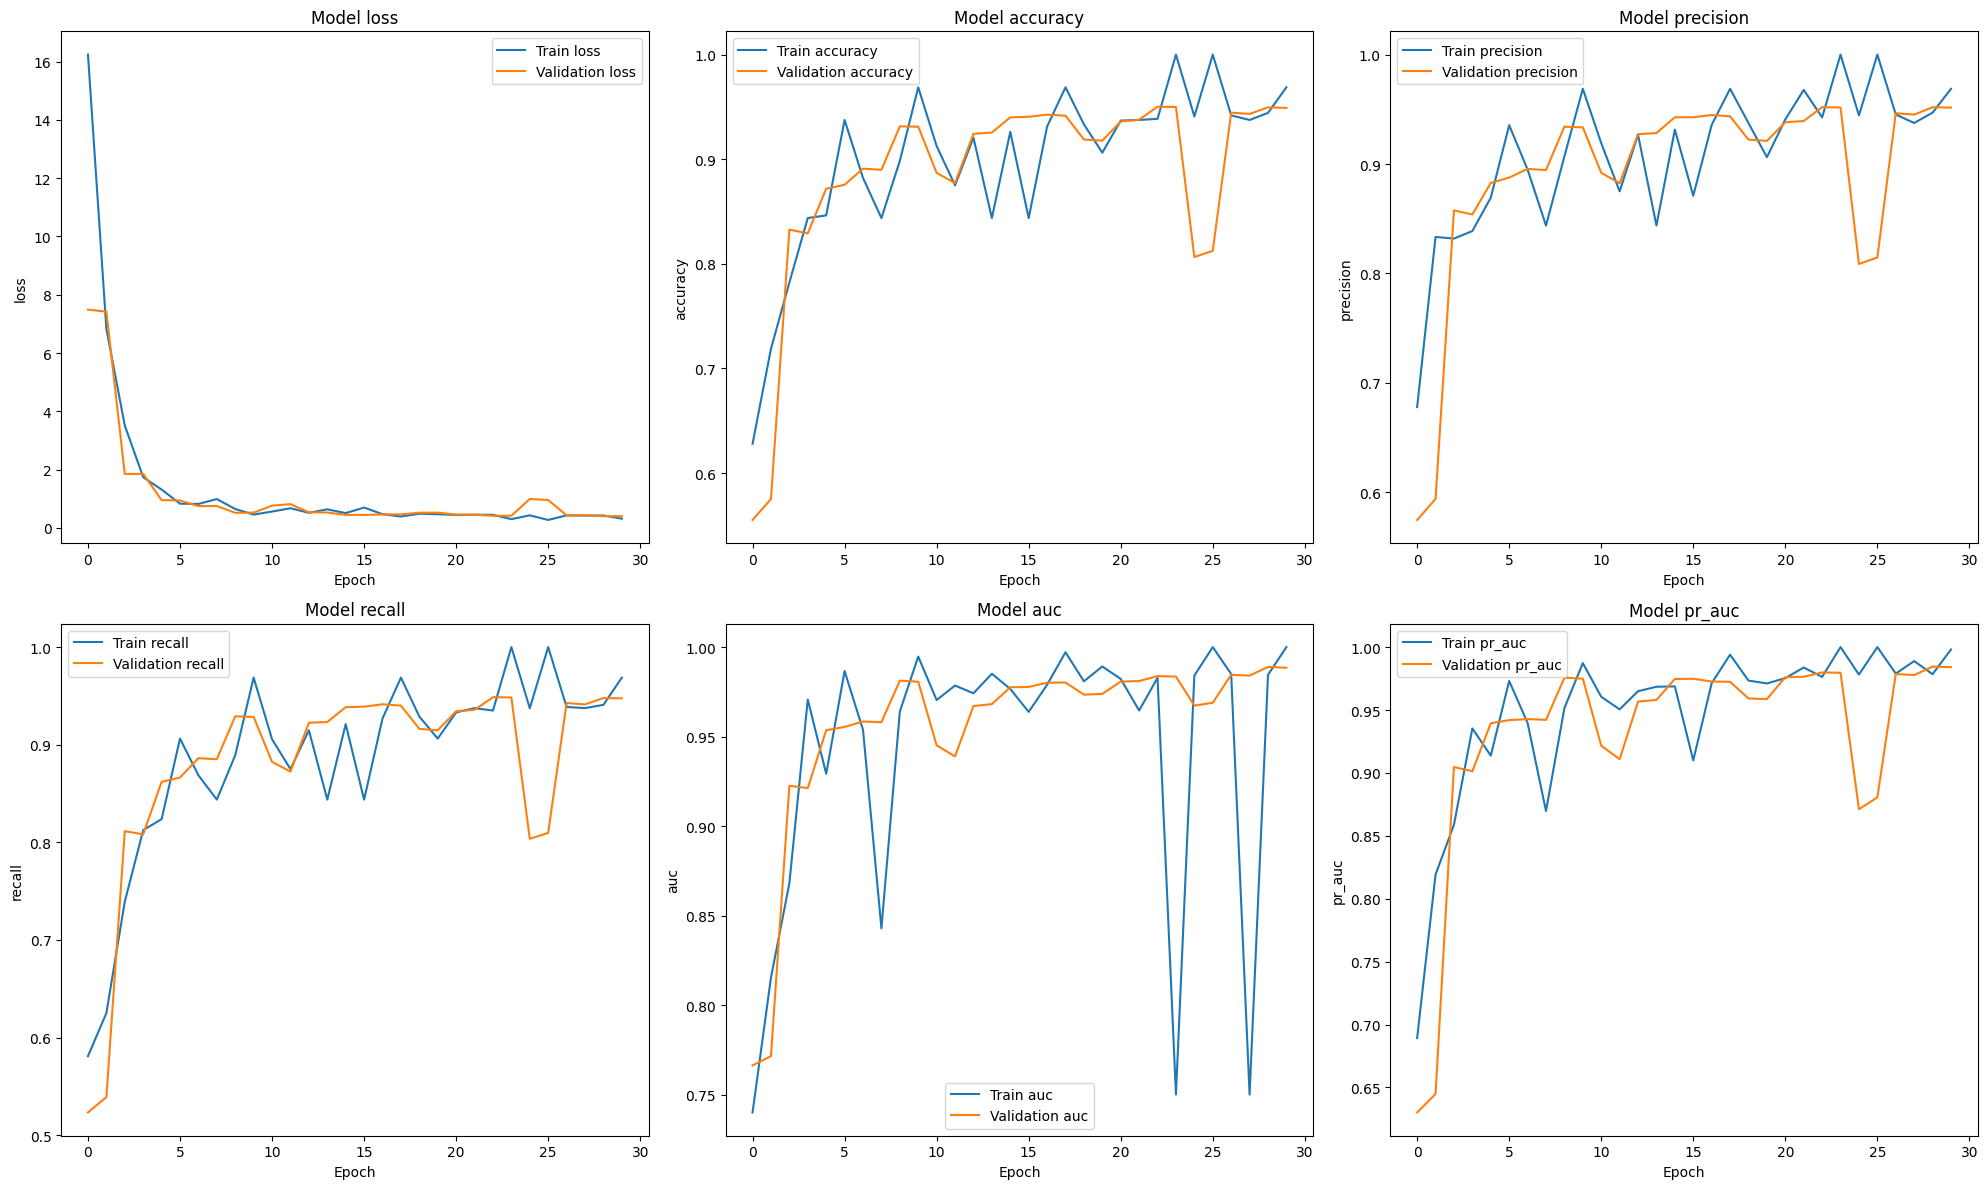

In [ ]:
# Plot training history
def plot_history(history):
    metrics = ['loss', 'accuracy', 'precision', 'recall', 'auc', 'pr_auc']

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel()

    for i, metric in enumerate(metrics):
        axes[i].plot(history.history[metric], label=f'Train {metric}')
        if f'val_{metric}' in history.history:
            axes[i].plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
        axes[i].set_title(f'Model {metric}')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel(metric)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# Model Evaluation on Test Set

In [ ]:
test_steps = test_generator.samples // batch_size
test_results = model.evaluate(test_generator, steps=test_steps, verbose=1)

print("\nTest Metrics:")
print(f'Loss: {test_results[0]:.4f}')
print(f'Accuracy: {test_results[1]:.4f}')
print(f'Precision: {test_results[2]:.4f}')
print(f'Recall: {test_results[3]:.4f}')
print(f'AUC-ROC: {test_results[4]:.4f}')
print(f'AUC-PR: {test_results[5]:.4f}')

341/341 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.9359 - auc: 0.5760 - loss: 0.4508 - pr_auc: 0.9779 - precision: 0.9394 - recall: 0.9333

Test Metrics:
Loss: 0.4163
Accuracy: 0.9488
Precision: 0.9510
Recall: 0.9468
AUC-ROC: 0.9871
AUC-PR: 0.9823


# Predictions and Classification Report

In [ ]:
# Generate predictions
test_generator.reset()
y_pred = model.predict(test_generator, steps=test_steps)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes[:len(y_pred_classes)]

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=classes))

341/341 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step

Classification Report:
              precision    recall  f1-score   support

         CNV       0.98      0.94      0.96      3746
         DME       0.95      0.88      0.91      1161
      DRUSEN       0.81      0.83      0.82       887
      NORMAL       0.95      0.99      0.97      5118

    accuracy                           0.95     10912
   macro avg       0.92      0.91      0.92     10912
weighted avg       0.95      0.95      0.95     10912



# confusion matrix

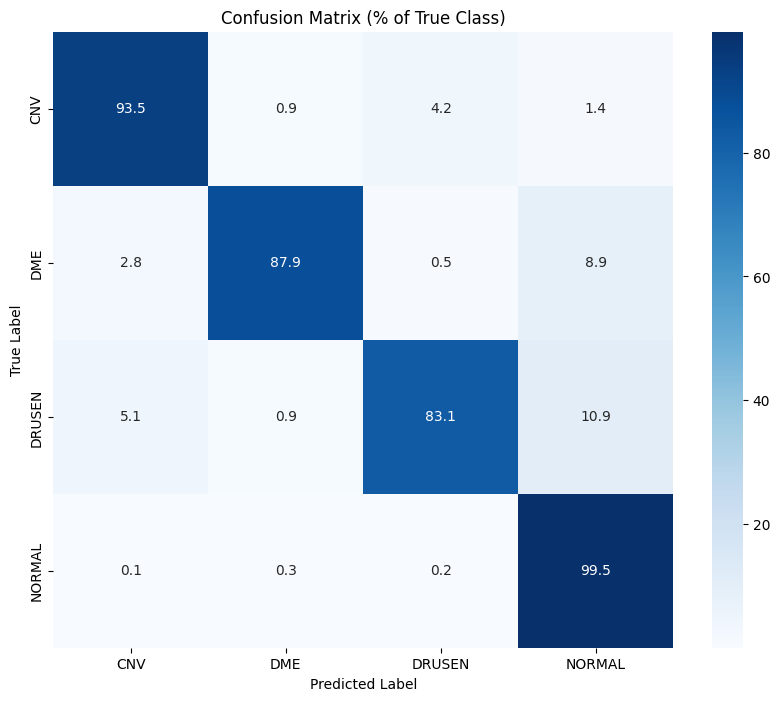

In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix (% of True Class)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig('outputs/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(y_true, y_pred_classes, classes)

# ROC Curve for multi-class

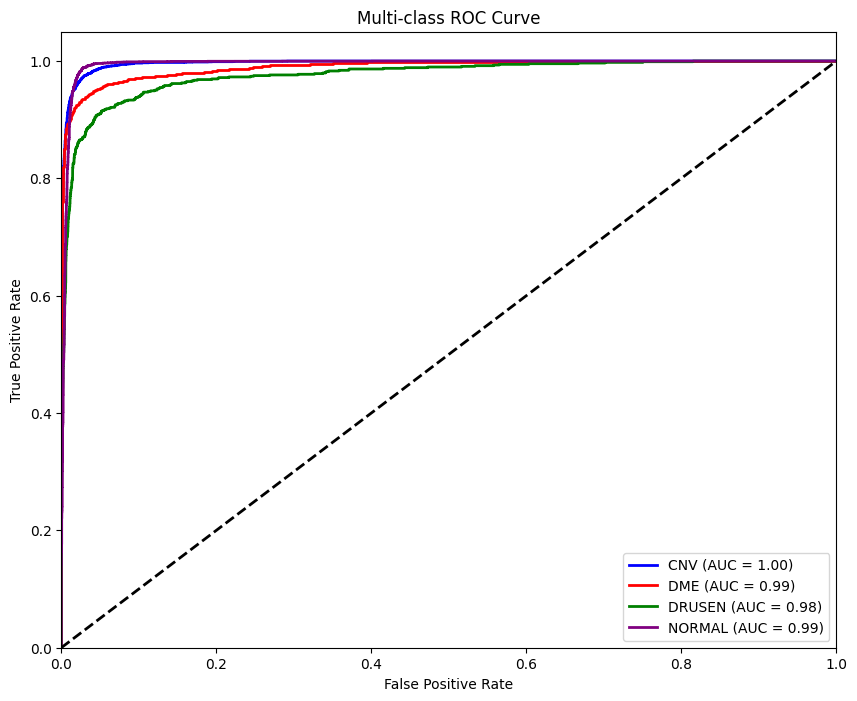

In [ ]:
y_test_bin = label_binarize(y_true, classes=np.arange(num_classes))
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'purple'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='{0} (AUC = {1:0.2f})'
             ''.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.savefig('outputs/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Precision-Recall Curve

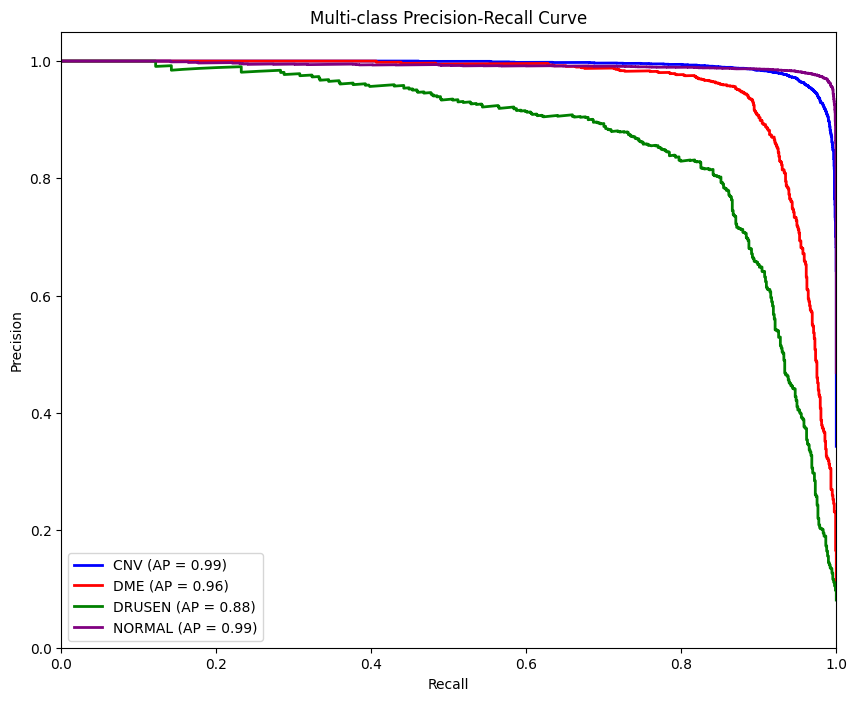

In [ ]:
precision = dict()
recall = dict()
pr_auc = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred[:, i])
    pr_auc[i] = average_precision_score(y_test_bin[:, i], y_pred[:, i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'purple'])

for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label='{0} (AP = {1:0.2f})'
             ''.format(classes[i], pr_auc[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Multi-class Precision-Recall Curve')
plt.legend(loc="lower left")
plt.savefig('outputs/precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot sample predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


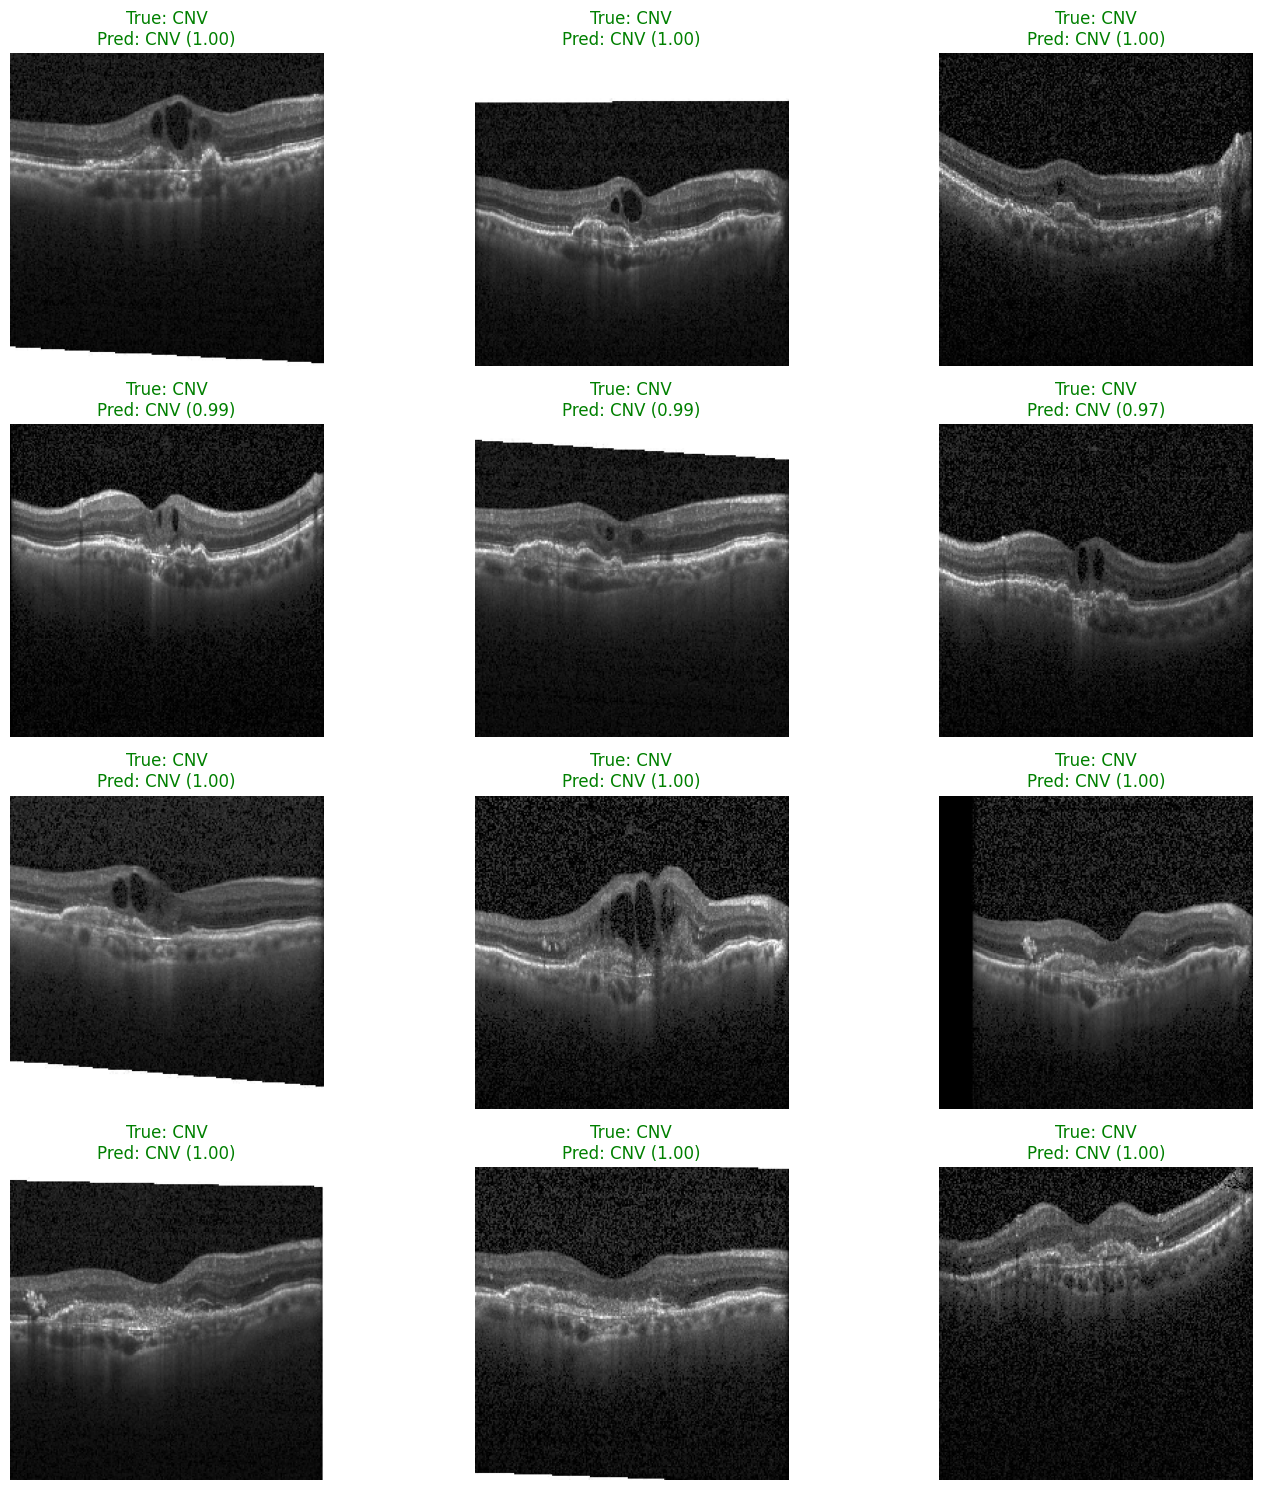

In [ ]:
def plot_sample_predictions(generator, model, num_samples=12):
    generator.reset()
    x, y = next(generator)
    preds = model.predict(x)

    plt.figure(figsize=(15, 15))
    for i in range(num_samples):
        plt.subplot(4, 3, i+1)
        plt.imshow(x[i].reshape(img_height, img_width), cmap='gray')

        true_class = classes[np.argmax(y[i])]
        pred_class = classes[np.argmax(preds[i])]
        confidence = np.max(preds[i])

        title_color = 'green' if true_class == pred_class else 'red'
        plt.title(f'True: {true_class}\nPred: {pred_class} ({confidence:.2f})', color=title_color)
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('outputs/sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_sample_predictions(test_generator, model)

# Class-wise metrics and save results

In [ ]:
# Class-wise metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred_classes)

class_metrics = pd.DataFrame({
    'Class': classes,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nClass-wise Metrics:")
print(class_metrics)

# Save metrics to CSV
class_metrics.to_csv('outputs/class_metrics.csv', index=False)
history_df = pd.DataFrame(history.history)
history_df.to_csv('outputs/training_history.csv', index=False)

# Save test results
test_metrics = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC', 'AUC-PR'],
    'Value': test_results
})
test_metrics.to_csv('outputs/test_metrics.csv', index=False)


Class-wise Metrics:
    Class  Precision    Recall  F1-Score  Support
0     CNV   0.977406  0.935398  0.955941     3746
1     DME   0.948837  0.878553  0.912343     1161
2  DRUSEN   0.811674  0.830891  0.821170      887
3  NORMAL   0.952844  0.994920  0.973428     5118


# Save the final model

In [ ]:
print("Saving the final model in H5 format...")
model.save('final_retinal_disease_model.h5')
print("Final model saved as 'final_retinal_disease_model.h5'")

# Also save the model in TensorFlow SavedModel format
model.export('final_retinal_disease_model')
print("Final model also saved in TensorFlow SavedModel format")

# Verify the model can be loaded correctly
print("Verifying model can be loaded...")
loaded_model = tf.keras.models.load_model('final_retinal_disease_model.h5')

# Test the loaded model
test_loss, test_accuracy, test_precision, test_recall, test_auc, test_pr_auc = loaded_model.evaluate(
    test_generator, steps=test_steps, verbose=0
)

print(f"\nLoaded Model Test Accuracy: {test_accuracy:.4f}")
print("Model saved and verified successfully!")

Saving the final model in H5 format...
Final model saved as 'final_retinal_disease_model.h5'
Saved artifact at 'final_retinal_disease_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name='keras_tensor_78')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133928465110928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928465111696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928465112080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928465113040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928465112848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928465112272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928465112656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928465111888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928465107472: TensorSpec(shape=(), dtype=tf.


Loaded Model Test Accuracy: 0.9488
Model saved and verified successfully!
